# Task 2 — News Headlines Analyzer

**Objective:** Collect news headlines from multiple websites, perform basic
text preprocessing, and analyze word frequency to identify trending topics.

**Sources:**
- BBC World News RSS Feed
- CNN RSS Feed
- Al Jazeera RSS Feed
- Reuters
- Fox News
- NBC News
- ABC News
- The Guardian
- DW News
- Euronews
- France 24
- AP News
- TIME

**Pipeline:**
1. Fetch RSS feeds from 3 major news sources
2. Parse XML with BeautifulSoup to extract headlines, dates, and descriptions
3. Store all headlines in a Pandas DataFrame
4. Perform text preprocessing (lowercasing, punctuation removal, stopword filtering)
5. Analyze word frequency and identify trending topics
6. Visualize findings with word clouds and bar charts

## 1. Import Libraries

In [1]:
# requests fetches the RSS feed XML from each news source
import requests

# BeautifulSoup parses XML/HTML — we use 'xml' parser for RSS feeds
from bs4 import BeautifulSoup

# Pandas for storing and analyzing headline data
import pandas as pd
import numpy as np

# re for regex-based text cleaning
import re

# collections.Counter counts word frequencies efficiently
from collections import Counter

# datetime for parsing publication dates
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# WordCloud for visual frequency representation
from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')
print('If WordCloud is missing, run: pip install wordcloud')


All libraries imported successfully.
If WordCloud is missing, run: pip install wordcloud


## 2. Configure News Sources

In [4]:
# ── RSS Feed URLs ─────────────────────────────────────────────────────────────
# RSS (Really Simple Syndication) feeds are public XML endpoints that news
# sites provide specifically for automated content reading.
# They are the most reliable way to collect headlines — no JS, no login,
# no bot detection, structured data ready to parse.
NEWS_SOURCES = {
    'BBC':          'http://feeds.bbci.co.uk/news/world/rss.xml',
    'CNN':          'http://rss.cnn.com/rss/edition.rss',
    'Al Jazeera':   'https://www.aljazeera.com/xml/rss/all.xml',
    'Sky News':     'https://feeds.skynews.com/feeds/rss/world.xml',
    'NPR':          'https://feeds.npr.org/1001/rss.xml',
    'Reuters':      'https://feeds.reuters.com/reuters/topNews',
    'Fox News':     'https://moxie.foxnews.com/google-publisher/world.xml',
    'NBC News':     'https://feeds.nbcnews.com/nbcnews/public/news',
    'ABC News':     'https://abcnews.go.com/abcnews/topstories',
    'The Guardian': 'https://www.theguardian.com/world/rss',
    'DW News':      'https://rss.dw.com/xml/rss-en-all',
    'Euronews':     'https://feeds.feedburner.com/euronews/en/home',
    'France 24':    'https://www.france24.com/en/rss',
    'AP News':      'https://feeds.apnews.com/ApNewsAlert',
    'TIME':         'https://time.com/feed/',
}

# ── Request headers ───────────────────────────────────────────────────────────
# RSS feeds are public but we still use a browser User-Agent
# to ensure the server responds with the full XML content.
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36',
    'Accept': 'application/rss+xml, application/xml, text/xml, */*',
}

print(f'Configured {len(NEWS_SOURCES)} news sources:')
for name, url in NEWS_SOURCES.items():
    print(f'  {name}: {url}')


Configured 15 news sources:
  BBC: http://feeds.bbci.co.uk/news/world/rss.xml
  CNN: http://rss.cnn.com/rss/edition.rss
  Al Jazeera: https://www.aljazeera.com/xml/rss/all.xml
  Sky News: https://feeds.skynews.com/feeds/rss/world.xml
  NPR: https://feeds.npr.org/1001/rss.xml
  Reuters: https://feeds.reuters.com/reuters/topNews
  Fox News: https://moxie.foxnews.com/google-publisher/world.xml
  NBC News: https://feeds.nbcnews.com/nbcnews/public/news
  ABC News: https://abcnews.go.com/abcnews/topstories
  The Guardian: https://www.theguardian.com/world/rss
  DW News: https://rss.dw.com/xml/rss-en-all
  Euronews: https://feeds.feedburner.com/euronews/en/home
  France 24: https://www.france24.com/en/rss
  AP News: https://feeds.apnews.com/ApNewsAlert
  TIME: https://time.com/feed/


## 3. Define Scraping Functions

In [7]:
def fetch_rss(source_name: str, url: str) -> list:
    """
    Fetches and parses an RSS feed from the given URL.

    RSS feeds are XML documents structured as:
      <rss>
        <channel>
          <item>
            <title>Headline text</title>
            <description>Short summary</description>
            <pubDate>Publication date</pubDate>
            <link>Article URL</link>
          </item>
          ...
        </channel>
      </rss>

    We parse each <item> tag and extract the relevant fields.
    Returns a list of dictionaries, one per headline.
    """
    try:
        response = requests.get(url, headers=HEADERS, timeout=15)

        if response.status_code != 200:
            print(f'  [!] {source_name}: HTTP {response.status_code}')
            return []

        # Parse XML content with BeautifulSoup using the 'xml' parser
        # 'xml' parser is more forgiving than 'lxml' for malformed XML
        soup = BeautifulSoup(response.content, 'xml')

        # Find all <item> elements — each represents one news article
        items = soup.find_all('item')

        if not items:
            # Some feeds use <entry> instead of <item> (Atom format)
            items = soup.find_all('entry')

        headlines = []
        for item in items:
            # ── Headline (title) ──────────────────────────────────────────────
            title_tag = item.find('title')
            title = title_tag.get_text(strip=True) if title_tag else ''

            # Skip empty titles
            if not title:
                continue

            # ── Description / summary ─────────────────────────────────────────
            desc_tag = item.find('description') or item.find('summary')
            description = desc_tag.get_text(strip=True) if desc_tag else ''
            # Remove any leftover HTML tags from description
            description = re.sub(r'<[^>]+>', '', description).strip()

            # ── Publication date ──────────────────────────────────────────────
            date_tag = item.find('pubDate') or item.find('published') or item.find('updated')
            pub_date = date_tag.get_text(strip=True) if date_tag else ''

            # ── Article URL ───────────────────────────────────────────────────
            link_tag = item.find('link')
            link = link_tag.get_text(strip=True) if link_tag else ''

            headlines.append({
                'source':      source_name,
                'title':       title,
                'description': description,
                'pub_date':    pub_date,
                'url':         link,
            })

        print(f'  {source_name}: {len(headlines)} headlines fetched')
        return headlines

    except Exception as e:
        print(f'  [!] {source_name}: Error — {e}')
        return []


print('Function defined: fetch_rss()')


Function defined: fetch_rss()


## 4. Fetch Headlines from All Sources

In [10]:
# ── Fetch from all news sources ───────────────────────────────────────────────
# We loop through each source, fetch its RSS feed, and accumulate
# all headlines into one master list.

all_headlines = []

print('Fetching headlines from all sources...')
for source_name, url in NEWS_SOURCES.items():
    headlines = fetch_rss(source_name, url)
    all_headlines.extend(headlines)

print(f'\nTotal headlines collected: {len(all_headlines)}')


Fetching headlines from all sources...
  BBC: 47 headlines fetched
  CNN: 50 headlines fetched
  Al Jazeera: 25 headlines fetched
  Sky News: 9 headlines fetched
  NPR: 10 headlines fetched
  [!] Reuters: Error — HTTPSConnectionPool(host='feeds.reuters.com', port=443): Max retries exceeded with url: /reuters/topNews (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000001E49B850350>: Failed to resolve 'feeds.reuters.com' ([Errno 11001] getaddrinfo failed)"))
  Fox News: 25 headlines fetched
  NBC News: 25 headlines fetched
  ABC News: 25 headlines fetched
  The Guardian: 45 headlines fetched
  DW News: 134 headlines fetched
  Euronews: 50 headlines fetched
  France 24: 23 headlines fetched
  [!] AP News: Error — HTTPSConnectionPool(host='feeds.apnews.com', port=443): Max retries exceeded with url: /ApNewsAlert (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000001E49B9C4800>: Failed to resolve 'feeds.apnews.com' ([Errno 1100

## 5. Load into Pandas DataFrame

In [13]:
# ── Create DataFrame ──────────────────────────────────────────────────────────
df = pd.DataFrame(all_headlines)

print(f'DataFrame shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print('\nHeadlines per source:')
print(df['source'].value_counts().to_string())
print('\nFirst 5 rows:')
df


DataFrame shape: (493, 5)
Columns: ['source', 'title', 'description', 'pub_date', 'url']

Headlines per source:
source
DW News         134
CNN              50
Euronews         50
BBC              47
The Guardian     45
Al Jazeera       25
Fox News         25
NBC News         25
ABC News         25
TIME             25
France 24        23
NPR              10
Sky News          9

First 5 rows:


,source,title,description,pub_date,url
0,BBC,"No sign of larger hantavirus outbreak, says UN...",The situation could still change and there mig...,"Tue, 12 May 2026 17:55:12 GMT",https://www.bbc.com/news/articles/cqjpqynj1nlo...
1,BBC,Trump says Iran ceasefire is on 'massive life ...,The US president criticises an Iranian counter...,"Tue, 12 May 2026 00:59:12 GMT",https://www.bbc.com/news/articles/cvgznxn18zgo...
2,BBC,Lebanon says two paramedics among 13 killed in...,Lebanon's health ministry says the paramedics ...,"Tue, 12 May 2026 20:00:05 GMT",https://www.bbc.com/news/articles/cx21j3xl72zo...
3,BBC,Zelensky's ex-chief of staff in court as Ukrai...,Andriy Yermak was named by Ukraine's two anti-...,"Tue, 12 May 2026 16:19:24 GMT",https://www.bbc.com/news/articles/c4g48kj40lwo...
4,BBC,US inflation jumps to 3.8% as energy costs sur...,The key measure of US inflation rises its high...,"Tue, 12 May 2026 18:36:58 GMT",https://www.bbc.com/news/articles/c202pgxx89lo...
...,...,...,...,...,...
488,TIME,Veolia,Mixed material waste for recycling moves along...,"Thu, 30 Apr 2026 13:22:21 +0000",https://time.com/collection/time100-most-influ...
489,TIME,GiveDirectly,"Agnes, Kenya, started a watermelon farm.","Thu, 30 Apr 2026 13:21:59 +0000",https://time.com/collection/time100-most-influ...
490,TIME,Letterboxd,,"Thu, 30 Apr 2026 13:21:33 +0000",https://time.com/collection/time100-most-influ...
491,TIME,Synchron,The Synchron Stentrode is a minimally invasive...,"Thu, 30 Apr 2026 13:21:19 +0000",https://time.com/collection/time100-most-influ...


## 6. Data Cleaning

In [16]:
# ── Remove duplicate headlines ────────────────────────────────────────────────
# The same story may appear across multiple sources with identical titles.
# We drop exact duplicates based on the title field.
before = len(df)
df = df.drop_duplicates(subset='title')
print(f'Duplicates removed: {before - len(df)} | Remaining: {len(df)}')


Duplicates removed: 0 | Remaining: 493


In [18]:
# ── Drop rows with empty titles ───────────────────────────────────────────────
before = len(df)
df = df[df['title'].str.strip() != '']
df = df.dropna(subset=['title'])
print(f'Empty titles removed: {before - len(df)} | Remaining: {len(df)}')


Empty titles removed: 0 | Remaining: 493


In [20]:
# ── Parse publication date ────────────────────────────────────────────────────
# RSS dates come in various formats (RFC 2822, ISO 8601).
# pd.to_datetime with errors='coerce' handles both gracefully.
df['pub_date'] = pd.to_datetime(df['pub_date'], errors='coerce', utc=True)

print('Date range of headlines:')
print(f'  Oldest: {df["pub_date"].min()}')
print(f'  Newest: {df["pub_date"].max()}')
print(f'  Missing dates: {df["pub_date"].isna().sum()}')


Date range of headlines:
  Oldest: 2026-05-01 05:13:00+00:00
  Newest: 2026-05-12 22:19:55+00:00
  Missing dates: 272


In [22]:
# ── Clean title text ──────────────────────────────────────────────────────────
# Store a cleaned version of the title for text analysis.
# We keep the original title intact for display purposes.
df['title_clean'] = (
    df['title']
    .str.strip()                          # Remove leading/trailing whitespace
    .str.replace(r'<[^>]+>', '', regex=True)   # Remove any HTML tags
    .str.replace(r'&amp;', '&', regex=True)    # Decode HTML entities
    .str.replace(r'&quot;', '"', regex=True)
    .str.replace(r'&#39;', "'", regex=True)
)

print('Title cleaning complete.')
print('\nSample cleaned titles:')
print(df[['source', 'title_clean']].head(10).to_string(index=False))


Title cleaning complete.

Sample cleaned titles:
source                                                                         title_clean
   BBC                        No sign of larger hantavirus outbreak, says UN health agency
   BBC                              Trump says Iran ceasefire is on 'massive life support'
   BBC                      Lebanon says two paramedics among 13 killed in Israeli strikes
   BBC         Zelensky's ex-chief of staff in court as Ukraine corruption probe escalates
   BBC                      US inflation jumps to 3.8% as energy costs surge from Iran war
   BBC Hamas 'weaponised' sexual violence in 7 October attacks, Israeli investigation says
   BBC                   Dali ship operator charged over deadly  Baltimore bridge collapse
   BBC                                            eBay rejects $55.5bn offer from GameStop
   BBC                                 Uganda's president sworn in for record seventh term
   BBC                            South A

## 7. Text Preprocessing

In [25]:
# ── Define stopwords ──────────────────────────────────────────────────────────
# Stopwords are common words (the, a, in, is, etc.) that appear frequently
# but carry no meaningful content for frequency analysis.
# We remove them so our frequency counts reflect actual topics, not grammar.
STOPWORDS = set([
    # Articles & prepositions
    'a', 'an', 'the', 'in', 'on', 'at', 'to', 'for', 'of', 'with',
    'from', 'by', 'about', 'as', 'into', 'through', 'during', 'before',
    'after', 'above', 'below', 'between', 'out', 'off', 'over', 'under',
    # Conjunctions
    'and', 'but', 'or', 'nor', 'so', 'yet', 'both', 'either', 'neither',
    'not', 'only', 'own', 'same', 'than', 'too', 'very',
    # Pronouns
    'i', 'me', 'my', 'we', 'our', 'you', 'your', 'he', 'him', 'his',
    'she', 'her', 'it', 'its', 'they', 'them', 'their', 'what', 'which',
    'who', 'whom', 'this', 'that', 'these', 'those',
    # Verbs (common)
    'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has',
    'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should',
    'may', 'might', 'shall', 'can', 'need', 'dare', 'ought', 'used',
    # News-specific common words (not meaningful for topic analysis)
    'says', 'said', 'say', 'new', 'also', 'one', 'two', 'three',
    'first', 'last', 'more', 'after', 'amid', 'how', 'why', 'when',
    'where', 'there', 'here', 'now', 'back', 'up', 'down', 'like',
    'get', 'got', 'make', 'made', 'take', 'took', 'go', 'goes', 'went',
])

print(f'Stopword list contains {len(STOPWORDS)} words.')


Stopword list contains 124 words.


In [27]:
def preprocess_text(text: str, stopwords: set) -> list:
    """
    Preprocesses a headline string into a list of meaningful tokens.

    Steps:
      1. Lowercase — so 'Trump' and 'trump' are counted as the same word
      2. Remove punctuation — strips . , ! ? ' " etc.
      3. Tokenize — split into individual words
      4. Remove stopwords — filter out common meaningless words
      5. Remove short tokens — words with fewer than 3 characters
         (e.g. 'US' kept, but 'a', 'an' removed at length filter)

    Returns a list of cleaned, meaningful word tokens.
    """
    if not isinstance(text, str):
        return []

    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove punctuation (keep only letters, digits, spaces)
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Step 3: Tokenize (split on whitespace)
    tokens = text.split()

    # Steps 4 & 5: Remove stopwords and short tokens
    tokens = [
        token for token in tokens
        if token not in stopwords and len(token) >= 3
    ]

    return tokens


# Apply preprocessing to every headline
# Creates a new column 'tokens' containing the cleaned word list per headline
df['tokens'] = df['title_clean'].apply(lambda t: preprocess_text(t, STOPWORDS))

# Count how many tokens each headline produced
df['token_count'] = df['tokens'].apply(len)

print(f'Preprocessing complete.')
print(f'Average tokens per headline: {df["token_count"].mean():.1f}')
print('\nSample tokenization:')
for _, row in df.head(5).iterrows():
    print(f'  Original:  {row["title_clean"]}')
    print(f'  Tokens:    {row["tokens"]}')
    print()


Preprocessing complete.
Average tokens per headline: 7.5

Sample tokenization:
  Original:  No sign of larger hantavirus outbreak, says UN health agency
  Tokens:    ['sign', 'larger', 'hantavirus', 'outbreak', 'health', 'agency']

  Original:  Trump says Iran ceasefire is on 'massive life support'
  Tokens:    ['trump', 'iran', 'ceasefire', 'massive', 'life', 'support']

  Original:  Lebanon says two paramedics among 13 killed in Israeli strikes
  Tokens:    ['lebanon', 'paramedics', 'among', 'killed', 'israeli', 'strikes']

  Original:  Zelensky's ex-chief of staff in court as Ukraine corruption probe escalates
  Tokens:    ['zelensky', 'chief', 'staff', 'court', 'ukraine', 'corruption', 'probe', 'escalates']

  Original:  US inflation jumps to 3.8% as energy costs surge from Iran war
  Tokens:    ['inflation', 'jumps', 'energy', 'costs', 'surge', 'iran', 'war']



## 8. Word Frequency Analysis

In [30]:
# ── Global word frequency across all sources ──────────────────────────────────
# We flatten all token lists into one single list, then count occurrences.
# Counter({word: count}) gives us the frequency of every word.

all_tokens = [token for tokens in df['tokens'] for token in tokens]
word_freq = Counter(all_tokens)

# Convert to DataFrame for easier manipulation and display
freq_df = pd.DataFrame(word_freq.most_common(50), columns=['word', 'count'])
freq_df['percentage'] = (freq_df['count'] / len(df) * 100).round(1)

print(f'Total unique words across all headlines: {len(word_freq)}')
print(f'Total word tokens: {len(all_tokens)}')
print('\nTop 30 most frequent words:')
print(freq_df.head(30).to_string(index=False))


Total unique words across all headlines: 2103
Total word tokens: 3679

Top 30 most frequent words:
      word  count  percentage
     trump     51        10.3
      iran     47         9.5
       war     26         5.3
      2026     22         4.5
   germany     21         4.3
     china     18         3.7
hantavirus     17         3.4
     world     16         3.2
     watch     16         3.2
      news     15         3.0
   starmer     13         2.6
   ukraine     11         2.2
    macron     11         2.2
  minister     11         2.2
    latest     11         2.2
   israeli     10         2.0
    summit     10         2.0
    israel     10         2.0
       man     10         2.0
    russia     10         2.0
    global     10         2.0
    africa      9         1.8
      year      9         1.8
       cup      9         1.8
     talks      9         1.8
  military      9         1.8
       oil      9         1.8
     right      9         1.8
      live      9         1.8
 

In [32]:
# ── Word frequency per source ─────────────────────────────────────────────────
# Analyze which words are most frequent in each news source separately.
# This reveals editorial differences between outlets.

print('Top 10 words per news source:\n')
for source in df['source'].unique():
    source_tokens = [
        token
        for tokens in df[df['source'] == source]['tokens']
        for token in tokens
    ]
    top_words = Counter(source_tokens).most_common(10)
    print(f'{source}:')
    print('  ' + ', '.join([f"{w} ({c})" for w, c in top_words]))
    print()


Top 10 words per news source:

BBC:
  world (5), hantavirus (4), iran (4), war (4), trump (3), israeli (3), year (3), cup (3), eurovision (3), outbreak (2)

CNN:
  see (5), trump (4), shows (3), family (2), indictment (2), russian (2), cafe (2), video (2), moment (2), reporter (2)

Al Jazeera:
  iran (7), war (5), trump (4), percent (2), high (2), stakes (2), downplays (2), gaza (2), conflict (2), red (2)

Sky News:
  israel (2), found (2), most (1), powerful (1), nuclear (1), missile (1), deployed (1), year (1), putin (1), qualifies (1)

NPR:
  house (2), openai (1), sam (1), altman (1), takes (1), stand (1), fend (1), elon (1), musk (1), accusations (1)

Fox News:
  trump (9), iran (7), former (3), oil (3), china (2), administration (2), migration (2), takes (2), chinese (2), regime (2)

NBC News:
  iran (4), trump (3), ship (3), americans (2), financial (2), marty (2), makary (2), fda (2), commissioner (2), fbi (2)

ABC News:
  watch (12), trump (7), iran (3), negotiations (2), live

## 9. Visualization

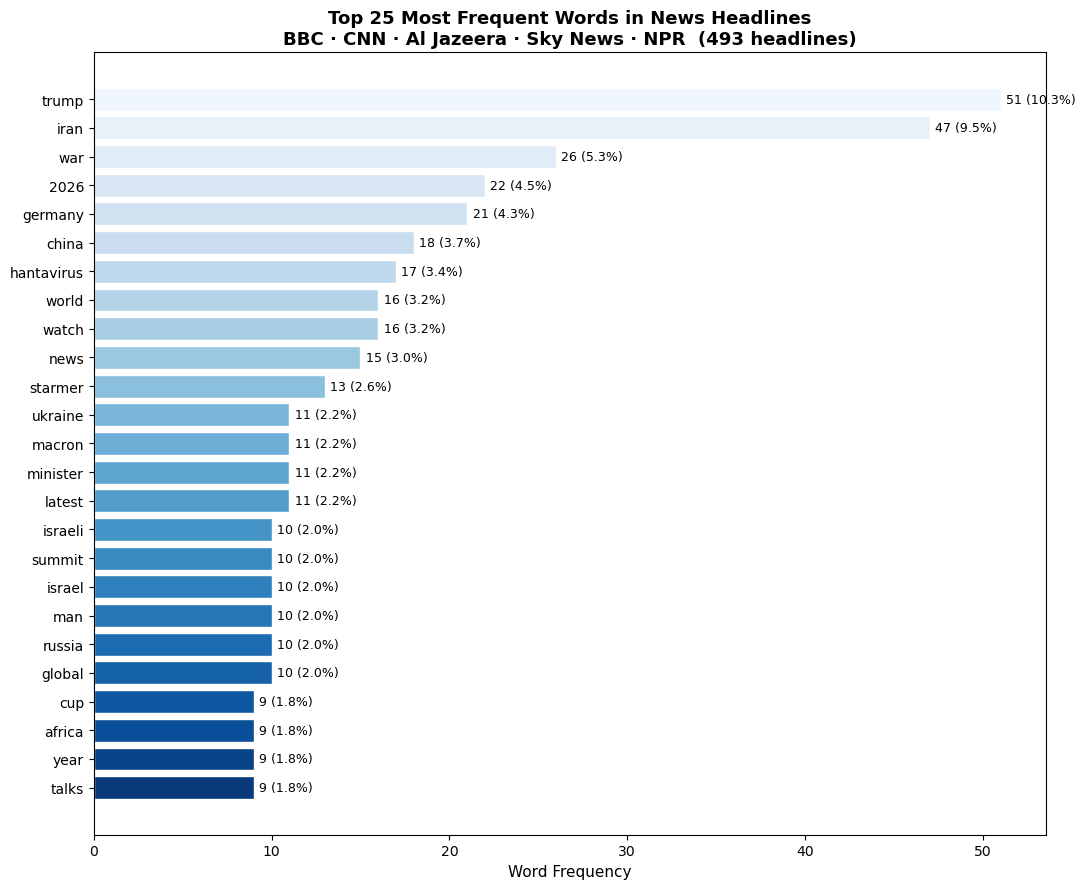

In [35]:
# ── Plot 1: Top 25 Most Frequent Words (All Sources) ──────────────────────────
top25 = freq_df.head(25).sort_values('count')

fig, ax = plt.subplots(figsize=(11, 9))
bars = ax.barh(
    top25['word'], top25['count'],
    color=sns.color_palette('Blues_r', len(top25)),
    edgecolor='white'
)
for bar, (_, row) in zip(bars, top25.iterrows()):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(row['count'])} ({row['percentage']}%)",
        va='center', fontsize=9
    )
ax.set_xlabel('Word Frequency', fontsize=11)
ax.set_title(
    f'Top 25 Most Frequent Words in News Headlines\n'
    f'BBC · CNN · Al Jazeera · Sky News · NPR  ({len(df)} headlines)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plot1_word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()


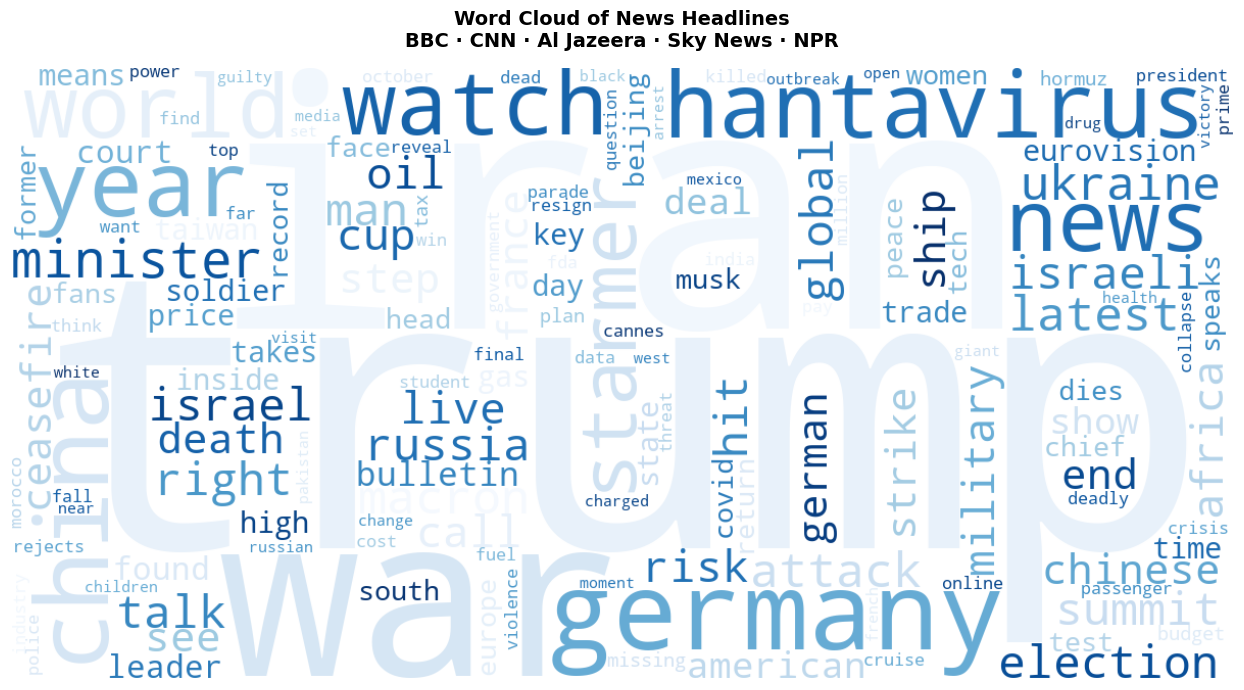

In [37]:
# ── Plot 2: Word Cloud ────────────────────────────────────────────────────────
# A word cloud visualizes word frequency — larger words appear more often.
# We pass the full token string to WordCloud which handles frequency internally.

text_for_cloud = ' '.join(all_tokens)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='Blues',
    max_words=150,           # Show top 150 words
    collocations=False,      # Avoid counting word pairs as single units
    min_font_size=10,
).generate(text_for_cloud)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title(
    'Word Cloud of News Headlines\nBBC · CNN · Al Jazeera · Sky News · NPR',
    fontsize=14, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('plot2_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()


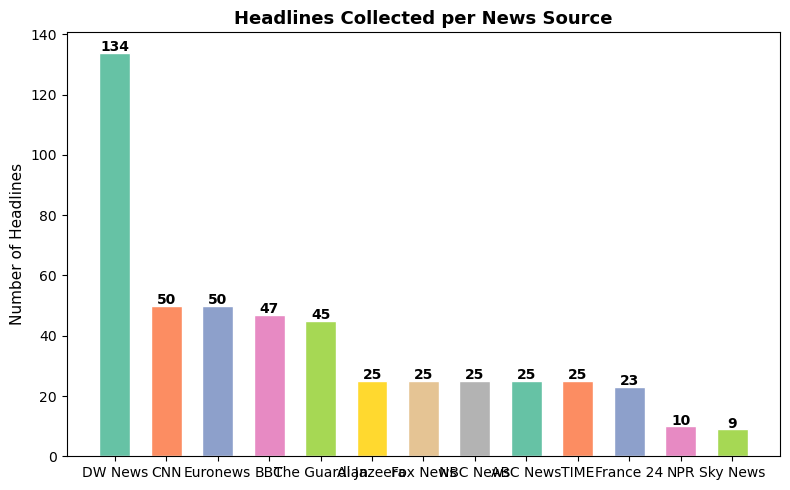

In [38]:
# ── Plot 3: Headlines Count per Source ───────────────────────────────────────
source_counts = df['source'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    source_counts.index, source_counts.values,
    color=sns.color_palette('Set2', len(source_counts)),
    edgecolor='white', width=0.6
)
for bar, val in zip(bars, source_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(val), ha='center', fontsize=10, fontweight='bold'
    )
ax.set_ylabel('Number of Headlines', fontsize=11)
ax.set_title('Headlines Collected per News Source',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_headlines_per_source.png', dpi=150, bbox_inches='tight')
plt.show()


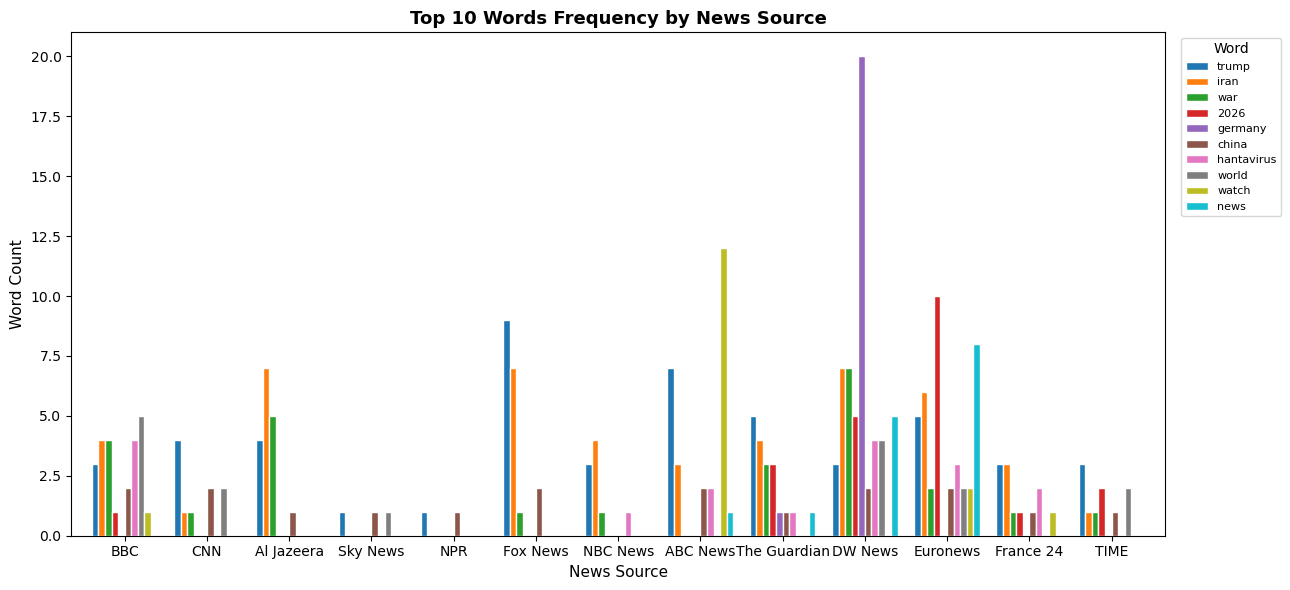

In [39]:
# ── Plot 4: Top 10 Words per Source (Grouped Bar Chart) ───────────────────────
# Compare which words dominate each source's headlines side by side.

# Get top 10 words overall as the reference set
top10_words = [w for w, _ in word_freq.most_common(10)]

# Build a matrix: rows = sources, columns = top10 words, values = counts
source_word_matrix = {}
for source in df['source'].unique():
    source_tokens = [
        t for tokens in df[df['source'] == source]['tokens']
        for t in tokens
    ]
    source_counter = Counter(source_tokens)
    source_word_matrix[source] = [source_counter.get(w, 0) for w in top10_words]

matrix_df = pd.DataFrame(source_word_matrix, index=top10_words)

fig, ax = plt.subplots(figsize=(13, 6))
matrix_df.T.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', width=0.8)
ax.set_xlabel('News Source', fontsize=11)
ax.set_ylabel('Word Count', fontsize=11)
ax.set_title('Top 10 Words Frequency by News Source',
             fontsize=13, fontweight='bold')
ax.legend(title='Word', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot4_words_by_source.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Export Results

In [44]:
# ── Save cleaned headlines to CSV ─────────────────────────────────────────────
# Convert tokens list to string for CSV compatibility
df['tokens_str'] = df['tokens'].apply(lambda t: ', '.join(t))

df.drop(columns='tokens').to_csv(
    'news_headlines_cleaned.csv', index=False, encoding='utf-8-sig'
)
print('Saved: news_headlines_cleaned.csv')

# Save word frequency table
freq_df.to_csv('news_word_frequency.csv', index=False)
print('Saved: news_word_frequency.csv')

print('\n' + '='*50)
print('FINAL SUMMARY')
print('='*50)
print(f'  Total headlines collected: {len(df)}')
print(f'  News sources:              {df["source"].nunique()}')
print(f'  Unique words found:        {len(word_freq)}')
print(f'  Total word tokens:         {len(all_tokens)}')
print(f'  Most frequent word:        "{freq_df.iloc[0]["word"]}" ({freq_df.iloc[0]["count"]} times)')
print(f'  Date range:                {df["pub_date"].min()} → {df["pub_date"].max()}')
print('='*50)


Saved: news_headlines_cleaned.csv
Saved: news_word_frequency.csv

FINAL SUMMARY
  Total headlines collected: 493
  News sources:              13
  Unique words found:        2103
  Total word tokens:         3679
  Most frequent word:        "trump" (51 times)
  Date range:                2026-05-01 05:13:00+00:00 → 2026-05-12 22:19:55+00:00
